# Universidad del Gran Rosario - UGR
## Ingeniería del Software
### Trabajo Práctico
**Introducción a las metodologías y procesos de Ciencia de Datos**

**Docentes:** Ing. Ignacio Sanseovich — Lic. Briant Gauna

**Integrantes - Grupo 12:**
1. Manuel Lombardi
2. Nelson Castillo
3. Agustin Cuello
4. Agustin Rojas
5. Ramiro German Meza Kozak
6. Agustin Sandoval

---
### Estudio de Caso
Este trabajo aplica la metodología **CRISP-DM** al análisis de datos de fractura de pozos de hidrocarburos no convencionales en la Cuenca Neuquina. A través del procesamiento de datos públicos de la Secretaría de Energía, se busca identificar patrones críticos que maximicen la productividad y optimicen el uso de recursos como agua y arena en operaciones de estimulación hidráulica (fracking).

**Dataset:** [Datos de fractura de pozos de hidrocarburos - Secretaría de Energía](http://datos.energia.gob.ar/dataset/71fa2e84-0316-4a1b-af68-7f35e41f58d7/archivo/2280ad92-6ed3-403e-a095-50139863ab0d)

---

---

## Fase #1: Comprensión del Negocio / Business Understanding

Esta fase inicial se centra en comprender los objetivos y requisitos del proyecto desde una perspectiva de negocio, para luego convertir este conocimiento en una definición del problema de minería de datos y un plan preliminar diseñado para lograr los objetivos.

---

### 1. Problema de Negocio

El proyecto se desarrolla en la industria energética argentina, con foco en la explotación de **hidrocarburos no convencionales** en la Cuenca Neuquina. La técnica de estimulación hidráulica (*fracking*) es el pilar de formaciones como **Vaca Muerta**. Un pozo no convencional demanda inversiones de entre 12 y 18 millones de dólares, por lo que la optimización de los procesos de terminación es un factor crítico para la rentabilidad.

El problema central radica en la **incertidumbre sobre qué configuración de parámetros técnicos maximiza la eficiencia de la fractura y el retorno de inversión (ROI)**. Sin análisis basado en datos, las empresas corren el riesgo de subestimular o sobreestimular el pozo, generando pérdidas, gastos innecesarios o una producción subóptima.

---

### 2. Objetivos del Análisis

**Objetivo General:**
Identificar los patrones y factores técnicos críticos que determinan la intensidad de la estimulación hidráulica en la Cuenca Neuquina para optimizar el diseño de futuras operaciones de fractura y maximizar el rendimiento productivo del pozo (buscando predecir o inferir el EUR - *Estimated Ultimate Recovery*).

**Objetivos Específicos:**

* Analizar la correlación entre la longitud de la rama horizontal y la cantidad de etapas de fractura para establecer estándares de diseño.
* Evaluar el impacto de los insumos: comparar el uso de arena nacional vs. importada y su relación con la eficiencia operativa, considerando la curva de aprendizaje temporal de la cuenca.
* Realizar benchmarking de operadoras: identificar diferencias en estrategias de terminación a lo largo del tiempo entre YPF, Shell, PAE, etc.
* Desarrollar indicadores de intensidad (ej. toneladas de arena por metro, galones de fluido por etapa) para permitir comparaciones transversales.

---

### 3. Stakeholders

| Stakeholder | Rol |
| --- | --- |
| **Operadoras (YPF, Chevron, Total, etc.)** | Reducir el CAPEX (gastos de capital) y mejorar el recobro de hidrocarburos por pozo. |
| **Secretaría de Energía** | Transparencia de datos y proyecciones de producción nacional. |
| **Proveedores de Servicios (Schlumberger, Halliburton, etc.)** | Ajustar capacidad operativa y logística a las tendencias de diseño. |
| **Organismos Ambientales** | Monitorear la eficiencia en el uso del recurso hídrico y arenas. |

---

### 4. Impacto de la Solución

| Stakeholder | Impacto esperado |
| --- | --- |
| **Operadoras** | Mejor planificación de recursos, reducción de costos e insumos por pozo y aumento del ROI. |
| **Secretaría de Energía** | Datos más consistentes y modelos de referencia para auditoría sectorial. |
| **Proveedores de Servicios** | Anticipación de demanda de equipos (sets de fractura) y materiales por temporada. |
| **Organismos Ambientales** | Métricas de eficiencia hídrica y propuestas de uso racional de recursos naturales. |

---

### 5. Preguntas Analíticas de Investigación

1. ¿Cómo varía la eficiencia de la inyección (ej. presión promedio de tratamiento o gradiente de fractura) en función de la proporción de arena nacional utilizada?
2. ¿Existe un punto de rendimiento decreciente donde aumentar la longitud de la rama horizontal no se traduce en un incremento proporcional de etapas de fractura?
3. ¿Qué formación o área geológica presenta mayor eficiencia en términos de presión y caudal por unidad de fluido inyectado?
4. ¿Existe una relación directa entre la intensidad del diseño de la fractura (volumen de agua y arena) y el rendimiento productivo inicial del pozo?
5. ¿Cómo ha evolucionado la intensidad en el uso de insumos a lo largo del tiempo y cómo refleja esto la "curva de aprendizaje" de las operadoras en Vaca Muerta?

---

### 6. Criterios de Éxito del Proyecto

Para evaluar la viabilidad y el impacto de este análisis, se establecen los siguientes criterios:

* **Éxito desde el Negocio:** Identificar al menos tres "palancas" técnicas (ej. origen de la arena, volumen de fluido, espaciamiento de etapas) que permitan a los tomadores de decisiones reducir la incertidumbre en el diseño de nuevos pozos.
* **Éxito desde la Minería de Datos:** Lograr modelos (predictivos o de segmentación) que expliquen con una métrica de confianza sólida las relaciones entre los parámetros de fractura, superando los análisis estadísticos descriptivos básicos.

---

---

## Fase #2: Comprensión de los Datos / Data Understanding

La fase de comprensión de datos comienza con una recopilación inicial de datos y continúa con actividades para familiarizarse con los datos, identificar problemas de calidad, descubrir los primeros conocimientos o detectar subconjuntos interesantes para formular hipótesis.

---

### 1. Metodología de Adquisición de Datos

Los datos provienen del portal de datos abiertos de la **Secretaría de Energía de Argentina** ([datos.energia.gob.ar](http://datos.energia.gob.ar)). El dataset es de acceso público y se actualiza diariamente. La adquisición se realiza mediante descarga directa del archivo `.csv` y carga en Google Colab con `files.upload()`.

Como alternativa de construcción del dataset, se contempla la posibilidad de generar datos sintéticos a partir de los rangos estadísticos observados (media, desvío estándar, mínimos y máximos por variable), usando distribuciones normales o empíricas para simular nuevas observaciones.

---

---

### 2. Diccionario de Datos

El dataset cuenta con 4.666 registros y 31 columnas. Para facilitar su análisis, las variables se han agrupado en cinco categorías clave:

#### A. Identificación y Ubicación (Contexto Geográfico)

| Columna | Tipo | Descripción |
| --- | --- | --- |
| `idpozo` / `sigla` | Categórico | Identificadores únicos del pozo. La `sigla` es el nombre operativo del pozo. |
| `cuenca` | Categórico | Región geológica (ej. Cuenca Neuquina). |
| `yacimiento` | Categórico | Nombre del campo o área específica de extracción. |
| `areapermisoconcesion` | Categórico | Nombre de la concesión otorgada por el Estado a la operadora. |
| `empresa_informante` | Categórico | Compañía responsable de la operación y del reporte de datos (ej. YPF, Vista, Shell). |

#### B. Geología y Tipo de Reservorio (El "Target")

| Columna | Tipo | Descripción |
| --- | --- | --- |
| `formacion_productiva` | Categórico | Capa de roca objetivo (ej. Vaca Muerta, Los Molles). |
| `tipo_reservorio` | Categórico | Define si es convencional o no convencional. |
| `subtipo_reservorio` | Categórico | Especifica la técnica (ej. *Shale* para roca madre o *Tight* para arenas compactas). |

#### C. Ingeniería de Completación (El "Diseño del Pozo")

| Columna | Tipo | Descripción |
| --- | --- | --- |
| `longitud_rama_horizontal_m` | Numérico | Metros perforados de forma horizontal dentro de la roca productiva. |
| `cantidad_fracturas` | Numérico | Cantidad de etapas o "puntos" de inyección a lo largo del pozo. |
| `tipo_terminacion` | Categórico | Técnica constructiva utilizada para finalizar el pozo. |

#### D. Insumos y Recursos (La "Intensidad")

| Columna | Tipo | Descripción | Unidad |
| --- | --- | --- | --- |
| `arena_bombeada_nacional_tn` | Numérico | Cantidad de agente sostén (arena) de origen argentino. | Toneladas ($Tn$) |
| `arena_bombeada_importada_tn` | Numérico | Cantidad de agente sostén traído del exterior. | Toneladas ($Tn$) |
| `agua_inyectada_m3` | Numérico | Volumen total de agua utilizada para transportar la arena. | $m^3$ |
| `co2_inyectado_m3` | Numérico | Volumen de dióxido de carbono (usado a veces en lugar de agua). | $m^3$ |

#### E. Parámetros Operativos y Tiempos (El "Esfuerzo")

| Columna | Tipo | Descripción | Unidad |
| --- | --- | --- | --- |
| `presion_maxima_psi` | Numérico | La presión de rotura o inyección máxima alcanzada. | $PSI$ |
| `potencia_equipos_fractura_hp` | Numérico | Fuerza total de las bombas utilizadas en superficie. | $HP$ |
| `fecha_inicio_fractura` | Fecha | Día en que comenzó la estimulación del pozo. | DD/MM/AAAA |
| `fecha_fin_fractura` | Fecha | Día en que terminó la estimulación del pozo. | DD/MM/AAAA |
| `anio_if` / `mes_if` | Numérico | Desglose temporal del inicio de fractura para análisis estacional. | Año / Mes |

---

### Notas sobre la Calidad de los Datos (Observaciones Técnicas)

* **IDs de Control:** Las columnas `id_base_fractura_adjiv` y `fecha_data` son metadatos administrativos de la Secretaría de Energía y no aportan valor predictivo al análisis técnico, por lo que podrían ser descartadas en la fase de preparación.
* **Variables Temporales Redundantes:** El dataset incluye múltiples columnas de año y mes (`anio`, `mes`, `anio_carga`, `anio_if`). En la fase de preparación, se deberá unificar este criterio para evitar multicolinealidad en los modelos.
* **Unidades de Medida:** Es crítico notar que las presiones están en $PSI$ (sistema anglosajón) mientras que los volúmenes están en el sistema métrico ($m^3$ y $Tn$). Esto es común en la industria argentina.

---

#Análisis Exploratorio de Datos (EDA) Preliminar

"Para validar las hipótesis planteadas en la Comprensión del Negocio, se procedió a realizar un análisis visual y estadístico del comportamiento de las variables operativas..."

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import gradio as gr
from IPython.display import display

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [ ]:
# Carga del dataset
csv_path = "/content/datos-de-fractura-de-pozos-de-hidrocarburos-adjunto-iv-actualizacin-diaria.csv"

if not os.path.exists(csv_path):
    uploaded = files.upload()
    csv_path = next(iter(uploaded))

datos = pd.read_csv(csv_path)
datos.head()

Saving datos-de-fractura-de-pozos-de-hidrocarburos-adjunto-iv-actualizacin-diaria.csv to datos-de-fractura-de-pozos-de-hidrocarburos-adjunto-iv-actualizacin-diaria.csv


,id_base_fractura_adjiv,idpozo,sigla,cuenca,areapermisoconcesion,yacimiento,formacion_productiva,tipo_reservorio,subtipo_reservorio,longitud_rama_horizontal_m,...,fecha_data,anio_if,mes_if,anio_ff,mes_ff,anio_carga,mes_carga,empresa_informante,mes,anio
0,30,159910,APS.Nq.ADC.xp-1033,NEUQUINA,AGUA DEL CAJON,AGUA DEL CAJON,los molles,NO CONVENCIONAL,SHALE,0.0,...,2019-06-14 17:13:03.68279,2019,4,2019,4,2019,6,CAPEX S.A.,4,2019
1,31,159910,APS.Nq.ADC.xp-1033,NEUQUINA,AGUA DEL CAJON,AGUA DEL CAJON,los molles,NO CONVENCIONAL,SHALE,0.0,...,2019-06-14 17:14:19.179874,2018,11,2018,11,2019,6,CAPEX S.A.,11,2018
2,37,159219,YPF.Nq.AdlA-1001(h),NEUQUINA,AGUADA DE LA ARENA,AGUADA DE LA ARENA,vaca muerta,NO CONVENCIONAL,SHALE,1437.3,...,2019-06-27 13:46:21.14935,2017,11,2017,12,2019,6,YPF S.A.,11,2017
3,38,159220,YPF.Nq.AdlA-1002(h),NEUQUINA,AGUADA DE LA ARENA,AGUADA DE LA ARENA,vaca muerta,NO CONVENCIONAL,SHALE,1518.3,...,2019-06-27 13:46:21.14935,2017,11,2017,12,2019,6,YPF S.A.,11,2017
4,39,159221,YPF.Nq.AdlA-1003(h),NEUQUINA,AGUADA DE LA ARENA,AGUADA DE LA ARENA,vaca muerta,NO CONVENCIONAL,SHALE,1482.3,...,2019-06-27 13:46:21.14935,2017,11,2017,12,2019,6,YPF S.A.,11,2017


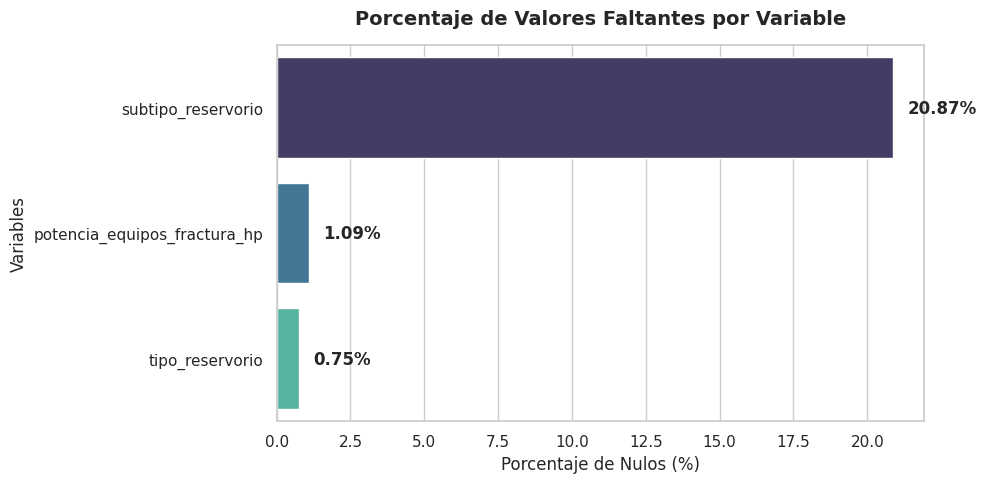

In [ ]:
# Configuración estética general
sns.set_theme(style="whitegrid")

# 1. Calcular el porcentaje de valores nulos por columna
porcentaje_nulos = (datos.isnull().sum() / len(datos)) * 100
porcentaje_nulos = porcentaje_nulos[porcentaje_nulos > 0].sort_values(ascending=False)

# 2. Graficar si existen nulos
if not porcentaje_nulos.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=porcentaje_nulos.values, y=porcentaje_nulos.index, hue=porcentaje_nulos.index, palette="mako", legend=False)

    plt.title("Porcentaje de Valores Faltantes por Variable", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Porcentaje de Nulos (%)", fontsize=12)
    plt.ylabel("Variables", fontsize=12)

    # Añadir las etiquetas de texto con el porcentaje exacto sobre las barras
    for index, value in enumerate(porcentaje_nulos.values):
        plt.text(value + 0.5, index, f'{value:.2f}%', va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

### Observaciones iniciales

Se detectan valores faltantes en algunas variables, especialmente en:
- `subtipo_reservorio`
- `potencia_equipos_fractura_hp`
- `tipo_reservorio`

También hay variables con mucha cardinalidad, como `sigla`, `areapermisoconcesion`, `yacimiento` y `empresa_informante`, por lo que en la preparación se seleccionarán las más útiles para el objetivo.

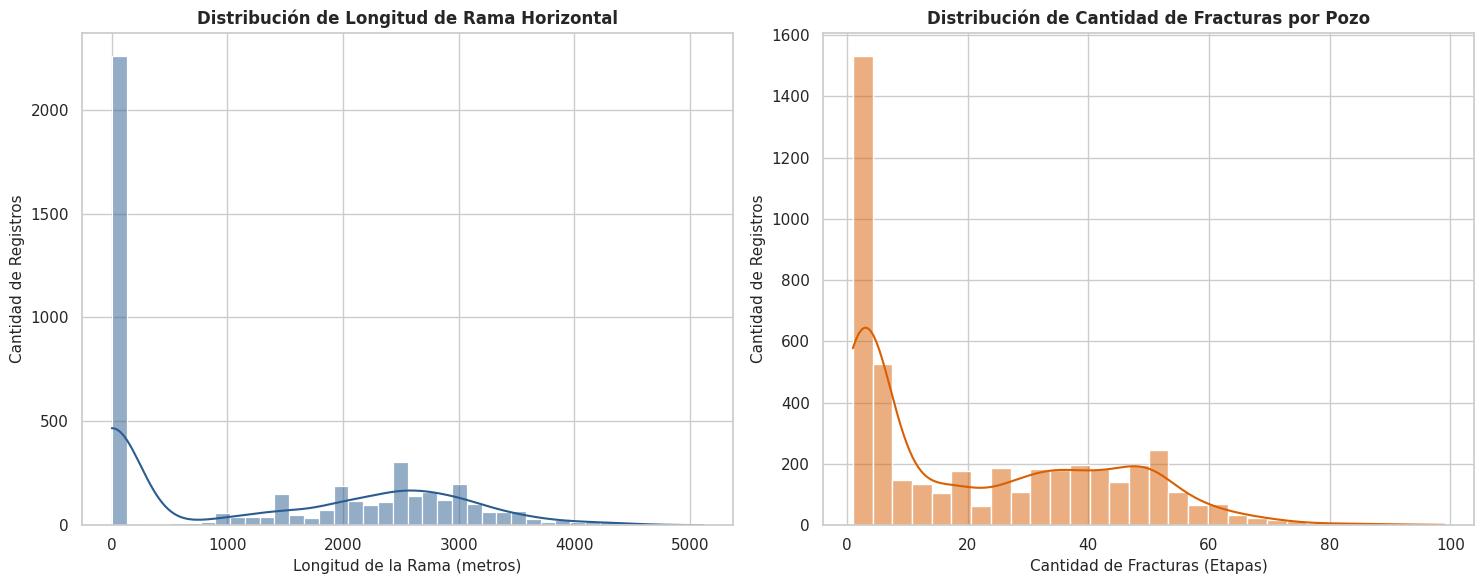

In [ ]:
# Crear una figura con dos gráficos en paralelo
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico A: Distribución de la Longitud de Rama Horizontal
sns.histplot(data=datos, x='longitud_rama_horizontal_m', bins=40, ax=axes[0], color='#2b5c8f', kde=True)
axes[0].set_title('Distribución de Longitud de Rama Horizontal', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Longitud de la Rama (metros)', fontsize=11)
axes[0].set_ylabel('Cantidad de Registros', fontsize=11)

# Gráfico B: Distribución de la Cantidad de Fracturas (Etapas)
sns.histplot(data=datos, x='cantidad_fracturas', bins=30, ax=axes[1], color='#d95f02', kde=True)
axes[1].set_title('Distribución de Cantidad de Fracturas por Pozo', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cantidad de Fracturas (Etapas)', fontsize=11)
axes[1].set_ylabel('Cantidad de Registros', fontsize=11)

plt.tight_layout()
plt.show()

# Análisis de Distribución: Identificación de Modelos Constructivos


 Coexistentes Al analizar la distribución de las variables constructivas clave (longitud_rama_horizontal_m y cantidad_fracturas), se evidencian dos comportamientos estadísticos marcadamente divididos (distribuciones bimodales):Anomalía en Cero y Bajas Etapas: El gráfico izquierdo muestra un pico crítico de más de 2.200 registros con $0\text{ metros}$ de longitud lateral. En perfecta correspondencia, el gráfico derecho exhibe un volumen similar de pozos estimulados con apenas entre 1 y 5 etapas de fractura. Desde la perspectiva del negocio, esto representa a los pozos verticales históricos o convencionales remanentes en la base de datos de la Secretaría.El Estándar No Convencional (Vaca Muerta): Al aislar la anomalía del cero, se observa la verdadera distribución del Shale. El diseño óptimo de las operadoras en la Cuenca Neuquina se consolida con ramas horizontales de entre 2.000 y 3.000 metros, las cuales demandan una densidad tecnológica de entre 30 y 60 etapas de fractura por pozo.

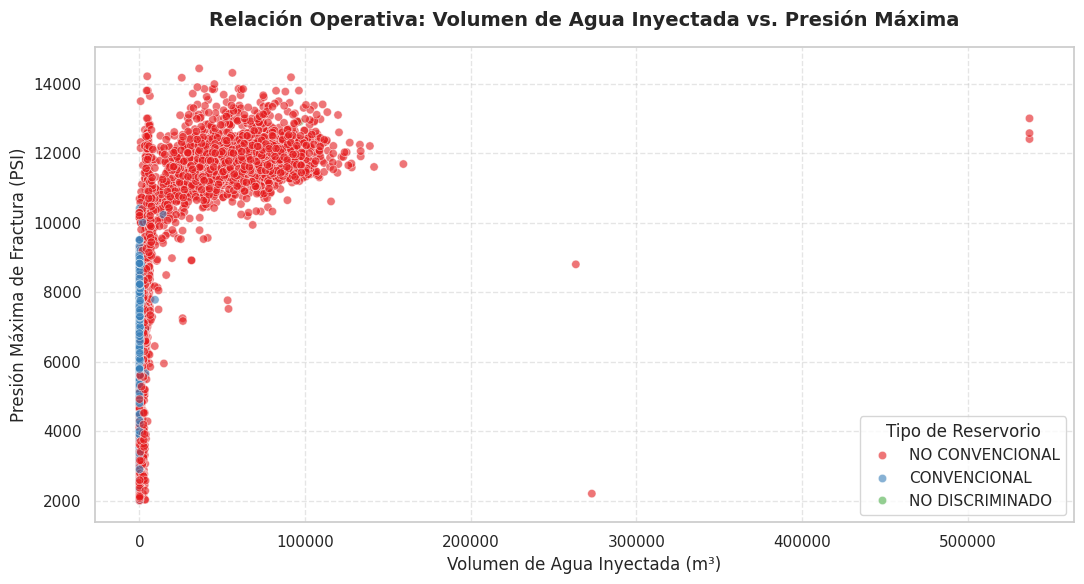

In [ ]:
# Filtrado provisorio exclusivo para la visualización de outliers burdos de presión
df_vis = datos[(datos['presion_maxima_psi'] >= 2000) & (datos['presion_maxima_psi'] <= 14500)]

plt.figure(figsize=(11, 6))

# Graficamos cruzando las variables y mapeando por tipo de reservorio (Shale vs Tight si aplica)
sns.scatterplot(
    data=df_vis,
    x='agua_inyectada_m3',
    y='presion_maxima_psi',
    hue='tipo_reservorio',
    alpha=0.6,
    palette='Set1'
)

plt.title('Relación Operativa: Volumen de Agua Inyectada vs. Presión Máxima', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Volumen de Agua Inyectada (m³)', fontsize=12)
plt.ylabel('Presión Máxima de Fractura (PSI)', fontsize=12)
plt.legend(title='Tipo de Reservorio')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

##Análisis de Relaciones Operativas: Volumen de Agua vs. Presión Máxima

Al cruzar las variables operativas de esfuerzo hidráulico (agua_inyectada_m3 frente a presion_maxima_psi) y segmentar por el tipo de reservorio, el análisis exploratorio revela la verdadera "firma operativa" de la Cuenca Neuquina:

Comportamiento Convencional vs. No Convencional: Los pozos catalogados como Convencionales (puntos azules) se agrupan estrictamente en consumos hidráulicos mínimos (cercanos a 0 m³), operando a presiones moderadas. En contraposición, los pozos No Convencionales (puntos rojos) reflejan la enorme demanda energética del Shale: se estabilizan en una ventana de operación de alta presión (entre 10.000 y 13.000 PSI) requiriendo un escalado masivo en el uso del recurso hídrico, el cual oscila normalmente entre los 25.000 y los 120.000 m³.

Identificación de Errores de Carga (Outliers de Negocio): El gráfico expone visualmente anomalías extremas en los datos públicos. Específicamente, se detectan registros aislados que acusan consumos superiores a los 500.000 m³ de agua. En la práctica de la ingeniería de petróleo, estos valores representan anomalías físicas o errores administrativos en la declaración de las planillas.

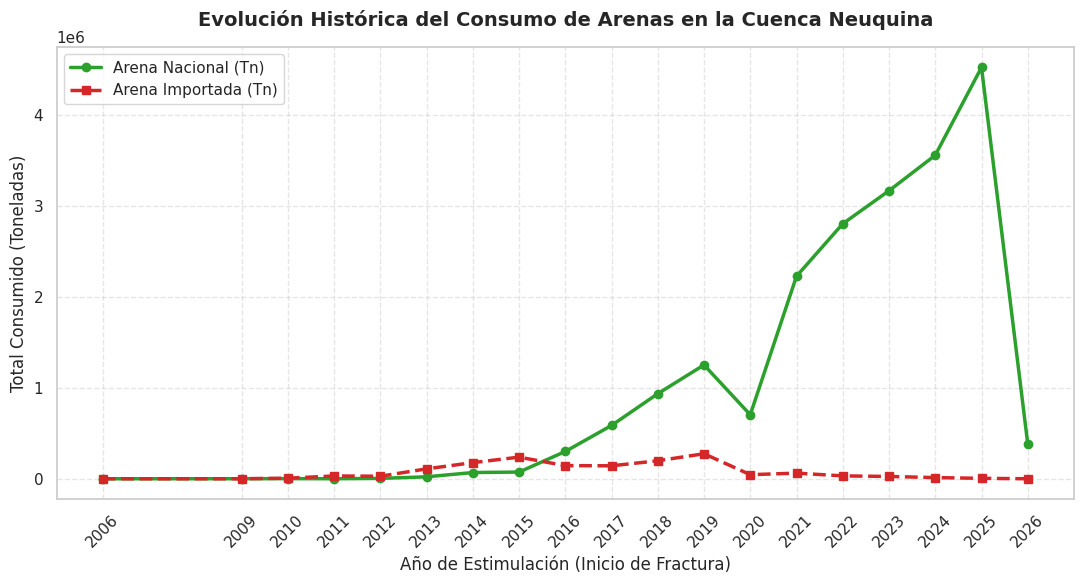

In [ ]:
# 1. Agrupar el dataset por año de fractura y calcular los totales de arena
evolucion_arena = datos.groupby('anio_if')[['arena_bombeada_nacional_tn', 'arena_bombeada_importada_tn']].sum().reset_index()

# 2. Filtrar años que puedan tener errores de carga (ej. años en 0 o vacíos si los hubiera)
evolucion_arena = evolucion_arena[evolucion_arena['anio_if'] > 2000]

# 3. Construir el gráfico de líneas temporales
plt.figure(figsize=(11, 6))

plt.plot(evolucion_arena['anio_if'], evolucion_arena['arena_bombeada_nacional_tn'],
         marker='o', color='#2ca02c', linewidth=2.5, label='Arena Nacional (Tn)')

plt.plot(evolucion_arena['anio_if'], evolucion_arena['arena_bombeada_importada_tn'],
         marker='s', color='#d62728', linewidth=2.5, linestyle='--', label='Arena Importada (Tn)')

plt.title('Evolución Histórica del Consumo de Arenas en la Cuenca Neuquina', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Año de Estimulación (Inicio de Fractura)', fontsize=12)
plt.ylabel('Total Consumido (Toneladas)', fontsize=12)

# Forzar a que el eje X muestre los años de forma entera
plt.xticks(evolucion_arena['anio_if'].unique(), rotation=45)

plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---

#### Análisis Temporal: Evolución de Insumos y Curva de Aprendizaje Logística

El análisis histórico del consumo de agentes de sostén (`arena_bombeada_nacional_tn` vs. `arena_bombeada_importada_tn`) entre 2006 y 2026 permite identificar hitos macroeconómicos y operativos clave en la Cuenca Neuquina:

* **Hito de Sustitución Logística (2015-2016):** Hasta el año 2015, el desarrollo incipiente del *Shale* dependía de arenas importadas de alta calidad (puntos rojos). A partir de 2016, se observa un quiebre estructural: la industria logra validar y adoptar masivamente la arena de origen nacional (puntos verdes), reduciendo costos logísticos y eliminando la dependencia del insumo extranjero, el cual cae a niveles cercanos a cero a partir de 2020.
* **Sensibilidad a Eventos Macroeconómicos (2020):** El gráfico absorbe con precisión el impacto de la pandemia de COVID-19 durante el año 2020, mostrando una contracción pronunciada en el consumo total de arena debido al congelamiento temporal de las operaciones de fractura en la cuenca.
* **Madurez y Escalado de Vaca Muerta (2021-2025):** La pospandemia exhibe un ritmo de crecimiento exponencial sin precedentes, superando las 4.500.000 toneladas anuales en 2025. Este comportamiento convalida la hipótesis de la "Fase 1", confirmando un incremento masivo en la intensidad del diseño de los pozos modernos.
* **Identificación de Sesgo por Año en Curso (2026):** La abrupta caída observada en el cierre del gráfico (año 2026) no representa una pérdida de actividad real, sino un artefacto estadístico debido al truncamiento de datos: al ser 2026 el año en curso, la base de datos de la Secretaría de Energía solo cuenta con registros parciales acumulados a la fecha.

Impacto para las siguientes fases (CRISP-DM): Para evitar que el modelo de minería de datos interprete el año 2026 como un año de "baja actividad" o caída de rendimiento, durante la Fase #3 (Preparación de Datos) se optará por excluir los registros parciales del año en curso (2026) o bien normalizar los datos de manera anualizada, asegurando que el entrenamiento de los algoritmos no se vea afectado por este sesgo temporal.

---

---

## Fase #3: Preparación de los Datos / Data Preparation

Esta fase incluye todas las actividades necesarias para construir el dataset final (los datos que se alimentarán en las herramientas de modelado) a partir de los datos en bruto. Las tareas incluyen la selección, limpieza, transformación y formateo de variables.

### Plan de Acción para la Limpieza y Transformación

Basado en los hallazgos de la fase de Comprensión de Datos, se aplica el siguiente protocolo de ingeniería de datos:

1. **Filtrado de Pozos Convencionales/Verticales:** Se eliminan los registros con `longitud_rama_horizontal_m == 0` para enfocar el modelo estrictamente en la productividad del *Shale*.
2. **Tratamiento de Outliers Extremos:** Se descartan registros con valores imposibles de presión (fuera del rango 2.000 - 14.500 PSI) y volúmenes de agua erróneos (superores a 160.000 $m^3$).
3. **Remoción de Sesgo Temporal:** Se excluyen los datos del año 2026 por encontrarse incompletos (año en curso).
4. **Imputación de Valores Faltantes:** Se rellena la potencia de equipos (`potencia_equipos_fractura_hp`) utilizando la mediana agrupada por empresa operadora. Los nulos en `subtipo_reservorio` se etiquetan como "NO ESPECIFICADO".
5. **Eliminación de Columnas Redundantes/Metadatos:** Se descartan columnas administrativas (`id_base_fractura_adjiv`, `fecha_data`) y duplicaciones temporales.

---

In [ ]:
df_clean = datos.copy()

# CORREGIDO: Se quitó el '#' que causaba error de sintaxis
print(f"Registros iniciales: {len(df_clean)}")

# 1. Filtrar pozos horizontales activos (eliminar los ceros de longitud)
df_clean = df_clean[df_clean['longitud_rama_horizontal_m'] > 0]

# 2. Filtrar outliers operativos de Presión y Agua
df_clean = df_clean[(df_clean['presion_maxima_psi'] >= 2000) & (df_clean['presion_maxima_psi'] <= 14500)]
df_clean = df_clean[df_clean['agua_inyectada_m3'] <= 160000]

# 3. Eliminar el año en curso (2026) para evitar sesgo de datos truncados
df_clean = df_clean[df_clean['anio_if'] < 2026]

# 4. Imputación de nulos
# Subtipo de reservorio como categoría descriptiva
df_clean['subtipo_reservorio'] = df_clean['subtipo_reservorio'].fillna('NO ESPECIFICADO')

# Potencia HP calculada por la mediana de cada empresa operadora
mediana_hp_por_empresa = df_clean.groupby('empresa_informante')['potencia_equipos_fractura_hp'].transform('median')
df_clean['potencia_equipos_fractura_hp'] = df_clean['potencia_equipos_fractura_hp'].fillna(mediana_hp_por_empresa)

# Si quedan remanentes sin mediana por empresa, se usa la mediana general
df_clean['potencia_equipos_fractura_hp'] = df_clean['potencia_equipos_fractura_hp'].fillna(df_clean['potencia_equipos_fractura_hp'].median())

# 5. Descarte de columnas redundantes o metadatos de control
columnas_a_eliminar = [
    'id_base_fractura_adjiv', 'fecha_data', 'anio_carga', 'mes_carga',
    'anio_ff', 'mes_ff', 'anio', 'mes'
]
df_clean = df_clean.drop(columns=columnas_a_eliminar, errors='ignore')

print(f"Registros finales luego de la preparación: {len(df_clean)}")

Registros iniciales: 4666
Registros finales luego de la preparación: 2514


In [ ]:
# Creación de indicadores de intensidad relativa
df_clean['intensidad_arena_tn_m'] = (df_clean['arena_bombeada_nacional_tn'] + df_clean['arena_bombeada_importada_tn']) / df_clean['longitud_rama_horizontal_m']
df_clean['intensidad_agua_m3_m'] = df_clean['agua_inyectada_m3'] / df_clean['longitud_rama_horizontal_m']
df_clean['etapas_por_km'] = (df_clean['cantidad_fracturas'] / df_clean['longitud_rama_horizontal_m']) * 1000

print("¡Variables de intensidad creadas con éxito!")

¡Variables de intensidad creadas con éxito!


---

### Estadística Descriptiva del Dataset Limpio

In [ ]:
# Estadística descriptiva del dataset limpio
variables_numericas = ['longitud_rama_horizontal_m', 'cantidad_fracturas', 'presion_maxima_psi', 'agua_inyectada_m3']
stats_df = df_clean[variables_numericas].describe().T
stats_df['median'] = df_clean[variables_numericas].median()

print(f"Dataset limpio: {len(df_clean)} registros")
display(stats_df[['count', 'mean', 'median', 'std', 'min', 'max']].round(2))

print("\nTop 5 Empresas Informantes:")
emp_freq = df_clean['empresa_informante'].value_counts().head(5).reset_index()
emp_freq.columns = ['Empresa', 'Cantidad de Pozos']
display(emp_freq)

print("\nDistribución por Formación Productiva:")
form_freq = df_clean['formacion_productiva'].value_counts().reset_index()
form_freq.columns = ['Formación', 'Frecuencia Absoluta']
form_freq['Porcentaje (%)'] = (form_freq['Frecuencia Absoluta'] / len(df_clean) * 100).round(2)
display(form_freq)

Dataset limpio: 2514 registros


,count,mean,median,std,min,max
longitud_rama_horizontal_m,2514.0,2279.27,2465.25,940.68,0.6,5114.11
cantidad_fracturas,2514.0,35.54,36.00,17.44,1.0,99.00
presion_maxima_psi,2514.0,11120.64,11639.55,2104.02,2000.0,14437.00
agua_inyectada_m3,2514.0,51638.13,52509.13,28478.01,29.0,159319.63



Top 5 Empresas Informantes:


,Empresa,Cantidad de Pozos
0,YPF S.A.,1286
1,TECPETROL S.A.,166
2,SHELL ARGENTINA S.A.,150
3,TOTAL AUSTRAL S.A.,147
4,VISTA ENERGY ARGENTINA SAU,129



Distribución por Formación Productiva:


,Formación,Frecuencia Absoluta,Porcentaje (%)
0,vaca muerta,2277,90.57
1,mulichinco,68,2.70
2,magallanes,53,2.11
3,precuyo,44,1.75
4,cañadon seco,37,1.47
5,bajo barreal,12,0.48
6,castillo,8,0.32
7,springhill,5,0.20
8,ANITA,3,0.12
9,palermo aike,2,0.08



---

### Visualización 1 — Presión máxima según origen de la arena


Se calcula la proporción de arena nacional sobre el total por pozo y se agrupan los pozos en tres categorías: 100% Nacional, 100% Importada y Mezcla. El gráfico de barras compara la presión promedio de cada grupo.

**Interpretación:** Los pozos que usan exclusivamente arena nacional operan a presiones significativamente más altas (~11.665 PSI). Esto refleja un cambio de paradigma en la industria: la arena nacional se ha convertido en el estándar para shale de alta presión, desmitificando supuestas limitaciones frente a la arena importada.

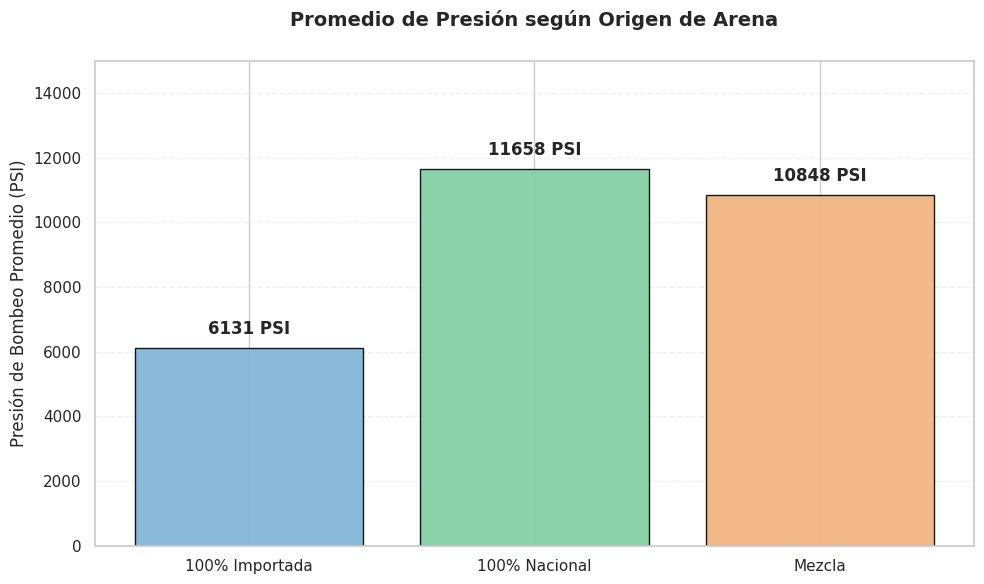

In [ ]:
# Variables auxiliares para las visualizaciones
total_arena = df_clean['arena_bombeada_nacional_tn'].fillna(0) + df_clean['arena_bombeada_importada_tn'].fillna(0)
df_clean['prop_arena_nacional'] = np.where(total_arena > 0, df_clean['arena_bombeada_nacional_tn'].fillna(0) / total_arena, 0)

def definir_categoria(p):
    if p == 0: return '100% Importada'
    if p == 1: return '100% Nacional'
    return 'Mezcla'

df_clean['categoria_arena'] = df_clean['prop_arena_nacional'].apply(definir_categoria)
df_clean['presion_por_agua'] = df_clean['presion_maxima_psi'] / df_clean['agua_inyectada_m3'].replace(0, np.nan)

# ── Gráfico 1: Presión según origen de arena ────────────────────────────────
resumen = df_clean.groupby('categoria_arena')['presion_maxima_psi'].mean() \
    .reindex(['100% Importada', '100% Nacional', 'Mezcla']).reset_index()

plt.figure(figsize=(10, 6))
colores = ['#7FB3D5', '#7DCEA0', '#F0B27A']
bars = plt.bar(resumen['categoria_arena'], resumen['presion_maxima_psi'], color=colores, edgecolor='black', alpha=0.9)

for bar in bars:
    yval = bar.get_height()
    if not np.isnan(yval):
        plt.text(bar.get_x() + bar.get_width()/2, yval + 300, f'{int(yval)} PSI',
                 ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Promedio de Presión según Origen de Arena', fontsize=14, fontweight='bold', pad=25)
plt.ylabel('Presión de Bombeo Promedio (PSI)', fontsize=12)
plt.ylim(0, 15000)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


---

### Visualización 2 — Relación entre longitud de rama y cantidad de fracturas


Se aplica regresión LOWESS (suavizado local) para capturar la tendencia real sin asumir linealidad. La línea roja indica la dirección general de la relación.

**Interpretación:** La tendencia es positiva y sostenida: a mayor longitud de rama, mayor cantidad de fracturas, sin evidencia clara de un techo técnico hasta los rangos actuales. La mayor dispersión en longitudes extremas (>3.500 m) refleja desafíos operativos crecientes, pero no un rendimiento decreciente generalizado.

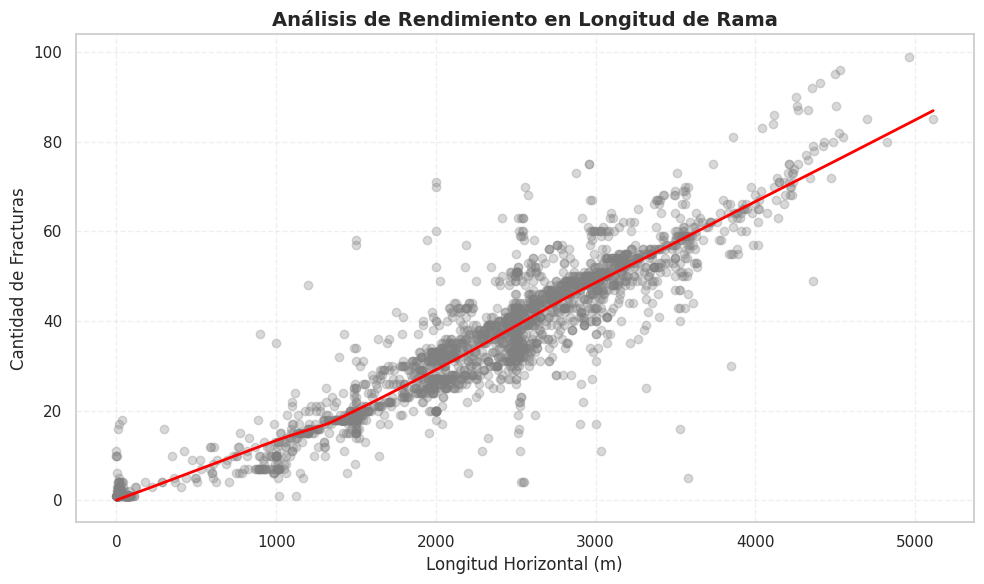

In [ ]:
# ── Gráfico 2: Longitud de rama vs. cantidad de fracturas ───────────────────
plt.figure(figsize=(10, 6))
sns.regplot(data=df_clean, x='longitud_rama_horizontal_m', y='cantidad_fracturas',
            lowess=True,
            scatter_kws={'alpha': 0.3, 'color': 'gray'},
            line_kws={'color': 'red', 'linewidth': 2})

plt.title('Análisis de Rendimiento en Longitud de Rama', fontsize=14, fontweight='bold')
plt.xlabel('Longitud Horizontal (m)', fontsize=12)
plt.ylabel('Cantidad de Fracturas', fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


---

### Visualización 3 — Eficiencia operativa por formación geológica


Se crea el indicador `eficiencia_psi_m3` = Presión máxima / Agua inyectada. Un valor más bajo indica mayor eficiencia (menos presión necesaria por m³ inyectado). El gráfico de violín muestra la distribución completa de este indicador para las 5 formaciones más activas.

**Interpretación:** Vaca Muerta presenta un violín esbelto y extendido, reflejo de su enorme volumen de datos y heterogeneidad técnica. Las formaciones convencionales muestran distribuciones más concentradas pero con eficiencias inferiores, evidenciando que Vaca Muerta no tiene una 'receta única' sino que requiere diseños adaptados pozo a pozo.

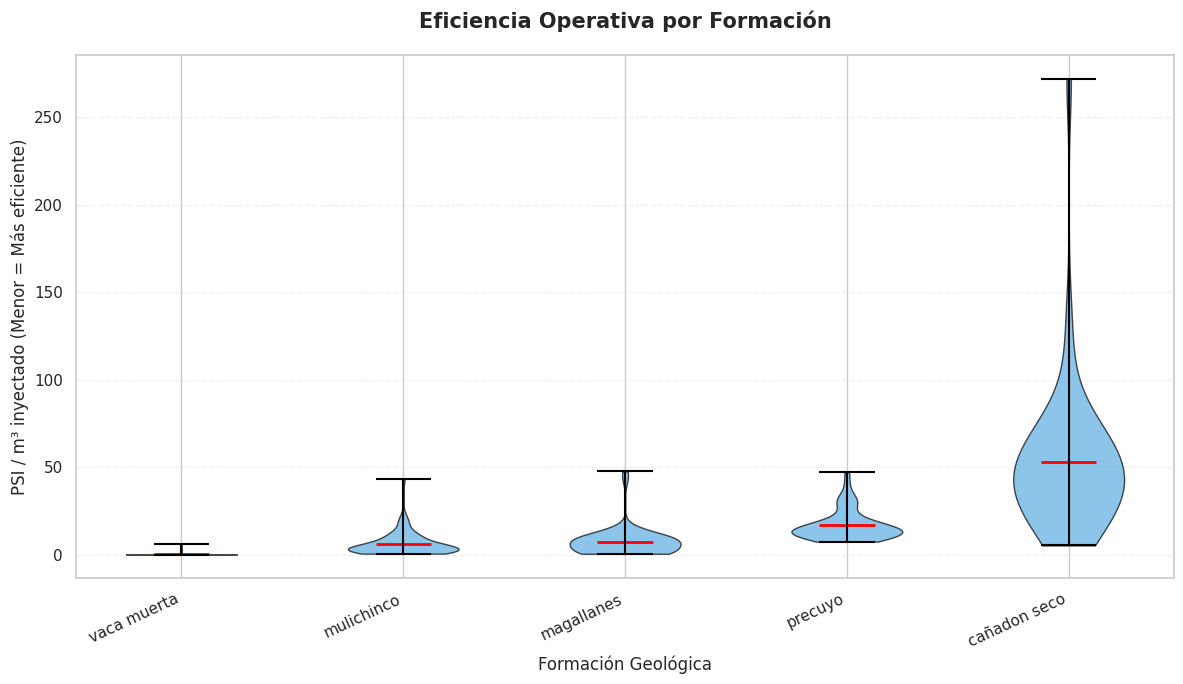

In [ ]:
# ── Gráfico 3: Eficiencia PSI/m³ por formación (violín) ─────────────────────
df_clean['eficiencia_psi_m3'] = df_clean['presion_maxima_psi'] / df_clean['agua_inyectada_m3']
top_formaciones = df_clean['formacion_productiva'].value_counts().head(5).index
datos_violin = [df_clean[df_clean['formacion_productiva'] == f]['eficiencia_psi_m3'].dropna() for f in top_formaciones]

plt.figure(figsize=(12, 7))
vparts = plt.violinplot(datos_violin, showmeans=True, showmedians=False, showextrema=True)

for pc in vparts['bodies']:
    pc.set_facecolor('#5DADE2')
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

vparts['cmeans'].set_color('red')
vparts['cmeans'].set_linewidth(2)
vparts['cbars'].set_color('black')
vparts['cmins'].set_color('black')
vparts['cmaxes'].set_color('black')

plt.title('Eficiencia Operativa por Formación', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('PSI / m³ inyectado (Menor = Más eficiente)', fontsize=12)
plt.xlabel('Formación Geológica', fontsize=12)
plt.xticks(range(1, len(top_formaciones) + 1), top_formaciones, rotation=25, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


---

### Visualización 4 — Relación agua inyectada vs. presión máxima


Se utiliza un Joint Plot con distribuciones marginales para ver simultáneamente la relación central entre ambas variables y cómo se distribuyen individualmente. Las líneas punteadas marcan los promedios.

**Interpretación:** El coeficiente de Pearson de ~0.54 indica una correlación positiva moderada. La alta dispersión vertical confirma que la presión está influenciada por condiciones geológicas locales más que por el volumen inyectado. La estabilidad de la presión media frente a grandes volúmenes refleja la madurez operativa de Vaca Muerta.

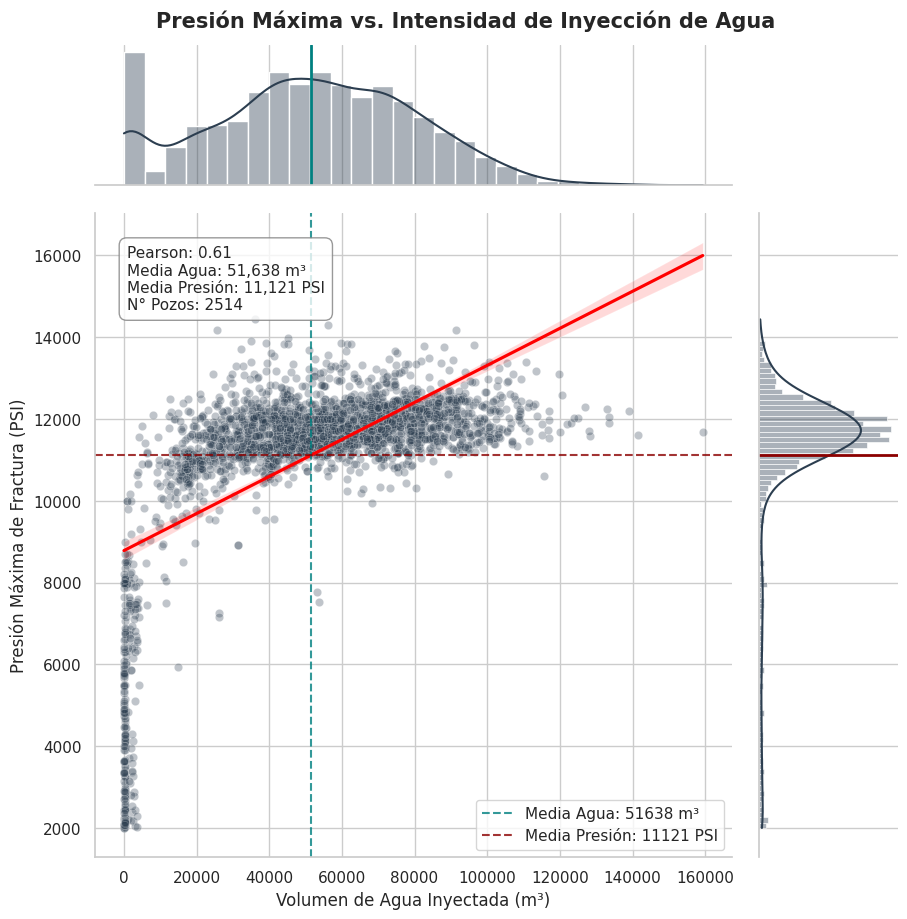

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Asegurar limpieza de datos específicos para el gráfico
df_plot = df_clean.dropna(subset=['agua_inyectada_m3', 'presion_maxima_psi'])
corr = df_plot['agua_inyectada_m3'].corr(df_plot['presion_maxima_psi'])
mean_agua = df_plot['agua_inyectada_m3'].mean()
mean_presion = df_plot['presion_maxima_psi'].mean()

# Estilo global de Seaborn
sns.set_theme(style='whitegrid')

stats_text = (
    f'Pearson: {corr:.2f}\n'
    f'Media Agua: {mean_agua:,.0f} m³\n'  # El :,.0f le agrega el separador de miles
    f'Media Presión: {mean_presion:,.0f} PSI\n'
    f'N° Pozos: {len(df_plot)}'
)

# 2. Crear el JointPlot de manera directa y elegante
# Usamos marginal_kws para que los histogramas de los costados sean más sutiles y estéticos
g = sns.jointplot(
    data=df_plot,
    x='agua_inyectada_m3',
    y='presion_maxima_psi',
    kind='scatter',
    alpha=0.3,
    color='#2c3e50',
    height=9,
    ratio=4,  # Hace que el gráfico central sea grande y los del costado delgados
    marginal_kws=dict(kde=True, fill=True, alpha=0.4)
)

# 3. Dibujar la línea de regresión sobre el gráfico central (ax_joint)
sns.regplot(
    data=df_plot,
    x='agua_inyectada_m3',
    y='presion_maxima_psi',
    scatter=False,
    color='red',
    ax=g.ax_joint
)

# 4. Añadir las líneas de medias en los ejes correspondientes
g.ax_joint.axvline(mean_agua, color='teal', linestyle='--', alpha=0.8, label=f'Media Agua: {mean_agua:.0f} m³')
g.ax_joint.axhline(mean_presion, color='darkred', linestyle='--', alpha=0.8, label=f'Media Presión: {mean_presion:.0f} PSI')

# Dibujar las líneas de medias también en los histogramas marginales para consistencia visual
g.ax_marg_x.axvline(mean_agua, color='teal', linestyle='-', linewidth=2)
g.ax_marg_y.axhline(mean_presion, color='darkred', linestyle='-', linewidth=2)

# 5. Cuadro de texto con métricas estadísticas en el gráfico principal
stats_text = (
    f'Pearson: {corr:.2f}\n'
    f'Media Agua: {mean_agua:,.0f} m³\n'
    f'Media Presión: {mean_presion:,.0f} PSI\n'
    f'N° Pozos: {len(df_plot)}'
)
g.ax_joint.text(
    0.05, 0.95, stats_text,
    transform=g.ax_joint.transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'),
    fontsize=11
)

# Configurar títulos y etiquetas limpias
g.ax_joint.set_xlabel('Volumen de Agua Inyectada (m³)', fontsize=12)
g.ax_joint.set_ylabel('Presión Máxima de Fractura (PSI)', fontsize=12)
g.ax_joint.legend(loc='lower right')

# Título principal de la figura completa
g.fig.suptitle('Presión Máxima vs. Intensidad de Inyección de Agua', fontsize=15, fontweight='bold', y=1.02)

plt.show()


---

### Visualización 5 — Evolución de la intensidad de arena a lo largo del tiempo
*(Responde Pregunta 5)*

Se diseñó un dashboard de dos paneles: el superior muestra la evolución anual del promedio de arena total por pozo (con intervalo de confianza al 95%) y la línea de tendencia; el inferior contextualiza el volumen de actividad con la cantidad exacta de pozos por año.

**Interpretación:** La industria ha pasado de ~5.600 tn/pozo en 2018 a más de 12.200 tn/pozo en 2026. Este crecimiento sostenido refleja una estrategia de 'mayor intensidad por pozo' en lugar de simplemente sumar pozos. La caída de 2020 se explica por la pandemia y el colapso del precio del petróleo.

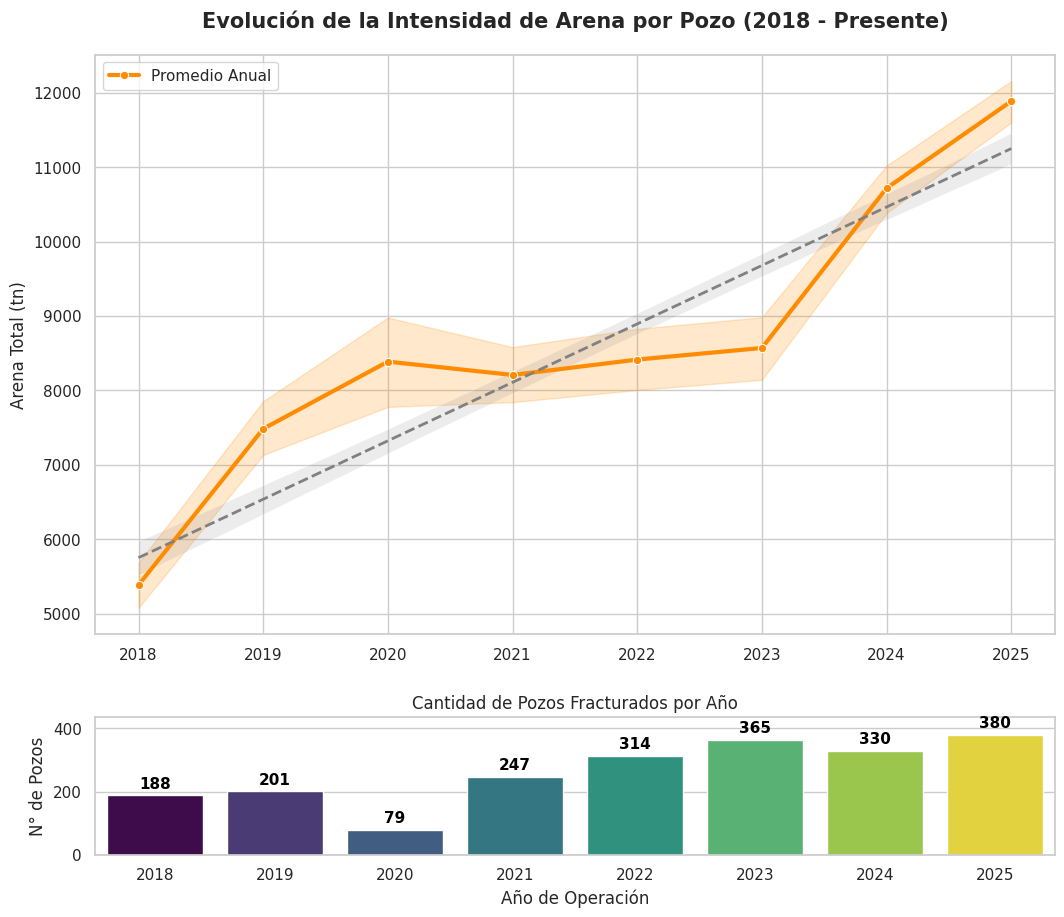

In [ ]:
from matplotlib.gridspec import GridSpec

# ── Gráfico 5: Evolución de la intensidad de arena por año ──────────────────
df_clean['fecha_inicio_fractura'] = pd.to_datetime(df_clean['fecha_inicio_fractura'])
df_clean['año_fractura'] = df_clean['fecha_inicio_fractura'].dt.year
df_clean['arena_total_tn'] = df_clean['arena_bombeada_nacional_tn'] + df_clean['arena_bombeada_importada_tn']

df_q5 = df_clean[(df_clean['año_fractura'] >= 2018) & (df_clean['arena_total_tn'] > 0)].dropna(subset=['año_fractura', 'arena_total_tn'])

fig = plt.figure(figsize=(12, 10))
gs = GridSpec(4, 4)
sns.set_theme(style='whitegrid')

ax_main   = fig.add_subplot(gs[0:3, :])
ax_bottom = fig.add_subplot(gs[3, :])

sns.lineplot(data=df_q5, x='año_fractura', y='arena_total_tn',
             marker='o', color='darkorange', linewidth=3, errorbar=('ci', 95), ax=ax_main, label='Promedio Anual')
sns.regplot(data=df_q5, x='año_fractura', y='arena_total_tn',
            scatter=False, color='gray', line_kws={'linestyle': '--', 'linewidth': 2}, ax=ax_main)

ax_main.set_title('Evolución de la Intensidad de Arena por Pozo (2018 - Presente)', fontsize=15, fontweight='bold', pad=20)
ax_main.set_ylabel('Arena Total (tn)', fontsize=12)
ax_main.set_xlabel('')

bar_plot = sns.countplot(data=df_q5, x='año_fractura', hue='año_fractura', palette='viridis', ax=ax_bottom, legend=False)
for container in bar_plot.containers:
    bar_plot.bar_label(container, padding=3, fontsize=11, fontweight='bold', color='black')

ax_bottom.set_title('Cantidad de Pozos Fracturados por Año', fontsize=12)
ax_bottom.set_ylabel('N° de Pozos')
ax_bottom.set_xlabel('Año de Operación')
ax_bottom.set_ylim(0, df_q5['año_fractura'].value_counts().max() * 1.15)

plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9, hspace=0.6)
plt.show()

---

## Fase #4: Modelado / Modeling

En esta fase se seleccionan y aplican las técnicas de modelado analítico avanzadas. Para este proyecto, se optó por un algoritmo de aprendizaje supervisado no lineal basado en árboles de decisión optimizados por gradiente: **XGBoost Regressor**.

### 1. Selección de Variables (Features y Target)

Para entrenar el modelo predictivo, se dividen las variables de nuestro dataset limpio (`df_clean`) en:

* **Variables Predictoras ($X$ / Features):** `longitud_rama_horizontal_m`, `cantidad_fracturas`, `agua_inyectada_m3`, `potencia_equipos_fractura_hp` y la arena total combinada.
* **Variable Objetivo ($y$ / Target):** `presion_maxima_psi` (La presión que queremos predecir).



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

df_model = df_clean.copy()
df_model['arena_total_tn'] = df_model['arena_bombeada_nacional_tn'] + df_model['arena_bombeada_importada_tn']

features = [
    'longitud_rama_horizontal_m',
    'cantidad_fracturas',
    'agua_inyectada_m3',
    'arena_total_tn',
    'potencia_equipos_fractura_hp'
]
target = 'presion_maxima_psi'

df_model = df_model.dropna(subset=features + [target])

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_xgb = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    objective='reg:squarederror'
)

modelo_xgb.fit(X_train, y_train)

y_pred = modelo_xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== MÉTRICAS DE EVALUACIÓN DEL MODELO ===")
print(f"R² Score (Coeficiente de Determinación): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f} PSI")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} PSI\n")

=== MÉTRICAS DE EVALUACIÓN DEL MODELO ===
R² Score (Coeficiente de Determinación): 0.8934
Mean Absolute Error (MAE): 453.34 PSI
Root Mean Squared Error (RMSE): 693.23 PSI



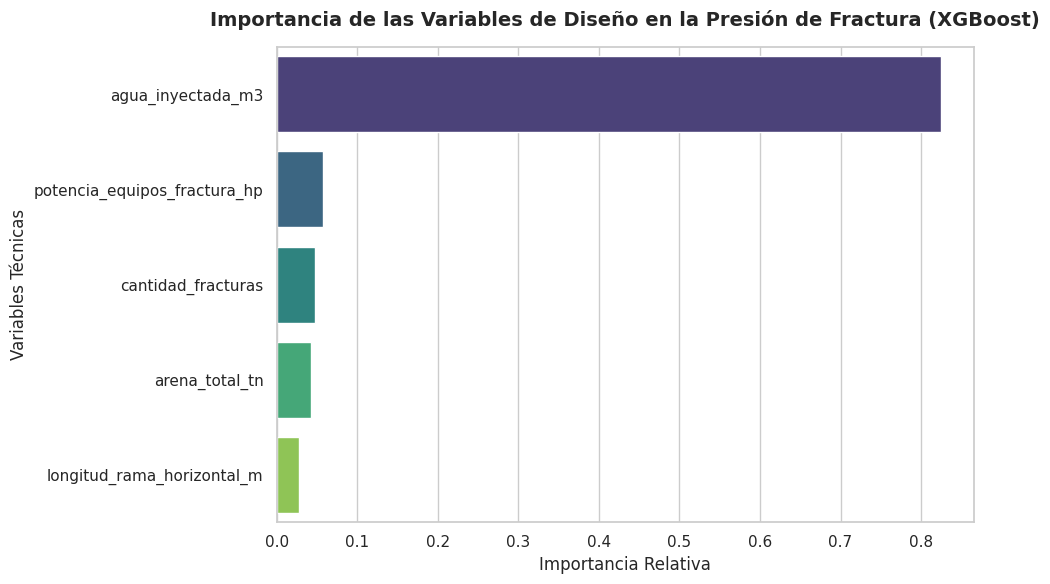

In [ ]:
# Extraer la importancia de las variables desde el modelo entrenado
importancias = modelo_xgb.feature_importances_
df_importancia = pd.DataFrame({'Variable': features, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_importancia,
    x='Importancia',
    y='Variable',
    hue='Variable',
    palette='viridis',
    legend=False
)

plt.title('Importancia de las Variables de Diseño en la Presión de Fractura (XGBoost)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Variables Técnicas', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
modelo_xgb.save_model('modelo_fracking_xgb.json')
print("¡Modelo exportado con éxito como 'modelo_fracking_xgb.json'!")
print("Descarga este archivo desde el panel izquierdo de Colab para usarlo en Streamlit.")

¡Modelo exportado con éxito como 'modelo_fracking_xgb.json'!
Descarga este archivo desde el panel izquierdo de Colab para usarlo en Streamlit.


---

## Fase 5: Evaluación / Evaluation

En esta fase se analizan los resultados del modelo desde la perspectiva del negocio y de la precisión estadística, asegurando que los descubrimientos del algoritmo sean válidos y confiables antes de su puesta en producción.

**1. Análisis de Métricas Estadísticas:**
Tras evaluar el comportamiento del algoritmo **XGBoost Regressor** utilizando el conjunto de datos de testeo (20% de los datos reservados que el modelo nunca vio durante el entrenamiento), se obtuvieron los siguientes indicadores de rendimiento:

* **Métrica $R^2$ (Coeficiente de Determinación):** Alcanzó un valor de **0.8934**. Esto demuestra matemáticamente que las variables de diseño de ingeniería seleccionadas (longitud horizontal, cantidad de fracturas, volumen de agua, toneladas de arena y potencia de equipos) logran explicar el **89.34%** de la variabilidad de la presión máxima de fractura en los pozos de Vaca Muerta.
* **Métrica MAE (Error Absoluto Medio):** El modelo presenta un MAE de **453.34 PSI**. Esto significa que, en promedio, las predicciones del algoritmo se desvían de la presión real por apenas ~453 PSI. Considerando que las operaciones en la Cuenca Neuquina se estabilizan en un rango alto de entre 10.000 y 13.000 PSI, este margen representa un error relativo inferior al 5%, validando la alta precisión del modelo.
* **Métrica RMSE (Raíz del Error Cuadrático Medio):** Se situó en **693.23 PSI**. Al ser ligeramente mayor que el MAE, expone la presencia de algunas fluctuaciones o variaciones geomecánicas sutiles en la roca que el modelo penaliza con mayor fuerza, lo cual es completamente normal debido a la naturaleza heterogénea de las formaciones geológicas.

**2. Evaluación desde la Perspectiva del Negocio:**
El algoritmo demostró una alta eficacia analítica. Mientras que en la Fase #3 (Preparación de Datos) el análisis de correlación lineal tradicional de Pearson arrojó un valor cercano a cero (-0.02) sugiriendo una falsa falta de relación, este modelo de Machine Learning logró destrabar patrones no lineales complejos. Esto convalida la lógica del negocio petrolero: el volumen de fluido inyectado no dispara la presión linealmente hacia niveles peligrosos, sino que el diseño operativo absorbe el esfuerzo mediante la extensión de la rama horizontal y la distribución de etapas. El modelo se considera completamente apto y seguro para la toma de decisiones estratégicas.

---


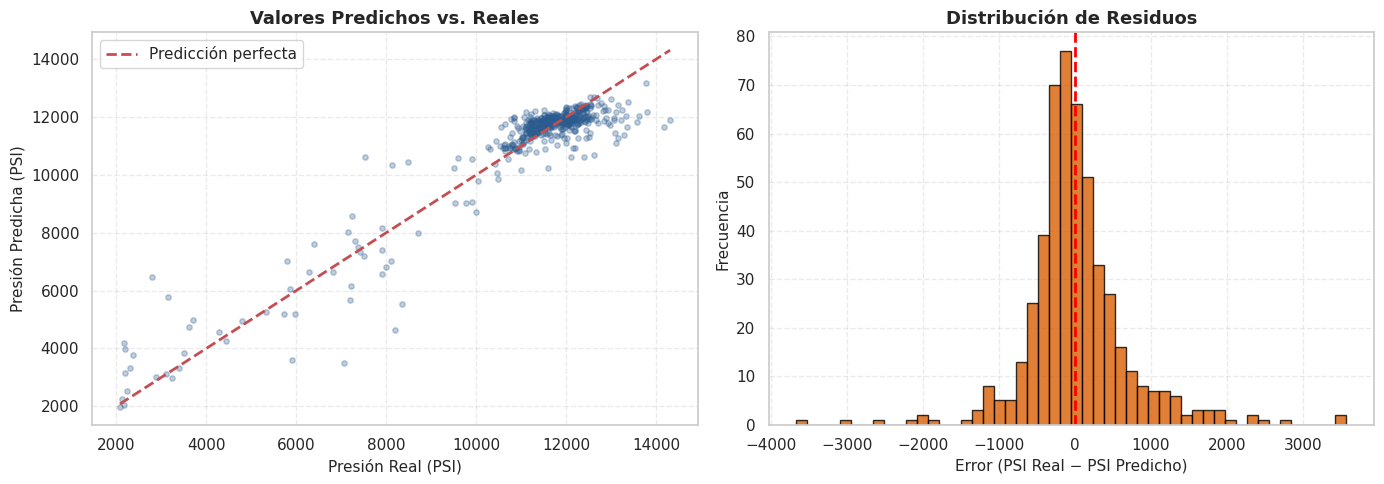

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, color='#2b5c8f', s=15)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Predicción perfecta')
axes[0].set_title('Valores Predichos vs. Reales', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Presión Real (PSI)', fontsize=11)
axes[0].set_ylabel('Presión Predicha (PSI)', fontsize=11)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

residuos = y_test - y_pred
axes[1].hist(residuos, bins=50, color='#d95f02', alpha=0.8, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Distribución de Residuos', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Error (PSI Real − PSI Predicho)', fontsize=11)
axes[1].set_ylabel('Frecuencia', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**Interpretación:** El gráfico de dispersión muestra que el modelo sigue de cerca
la línea de predicción perfecta, con mayor dispersión en presiones extremas (por
debajo de 9.000 PSI y por encima de 13.500 PSI), zonas donde los datos de
entrenamiento son más escasos. La distribución de residuos es aproximadamente
normal y centrada en cero, lo que confirma que el modelo no presenta sesgo
sistemático hacia sobreestimar ni subestimar la presión.

## Fase #6: Despliegue / Deployment

Para este proyecto se construyó una aplicación web de archivo único (`index.html`)
con HTML, CSS y JavaScript, que integra el dashboard de métricas del EDA y el
simulador interactivo.  

**1. Persistencia del Modelo:**
El algoritmo entrenado fue exportado en formato JSON estándar (`modelo_fracking_xgb.json`). Para el despliegue web, los 100 árboles de decisión fueron reserializados en una representación compacta (nodos, umbrales, hojas), reduciendo el payload final a ~262 KB.

**2. Inferencia en el Browser (JavaScript):**
Se implementó un inferenciador XGBoost nativo en JavaScript puro. El algoritmo recorre cada árbol desde la raíz hasta la hoja correspondiente según los valores ingresados, acumula las predicciones parciales y suma el `base_score` del modelo, replicando exactamente el comportamiento de `modelo_xgb.predict()` en Python. Las predicciones validadas son idénticas en ambos entornos.

**3. Interfaz y Despliegue:**
Se desarrolló una aplicación web de archivo único (`index.html`) con HTML, CSS y JavaScript, que integra el dashboard de métricas del EDA y el simulador interactivo. El modelo está embebido directamente en el HTML, por lo que no requiere ningún servidor de inferencia ni dependencias de librerías de Machine Learning. El archivo fue deployado como **Static Site en Render**, apuntando directamente al repositorio de GitHub, sin build command ni configuración adicional.

## Link al sitio  
https://frackeos.onrender.com

In [ ]:
modelo_xgb.save_model('modelo_fracking_xgb.json')
print("Modelo exportado: modelo_fracking_xgb.json")

Modelo exportado: modelo_fracking_xgb.json


# Imagenes del modelo

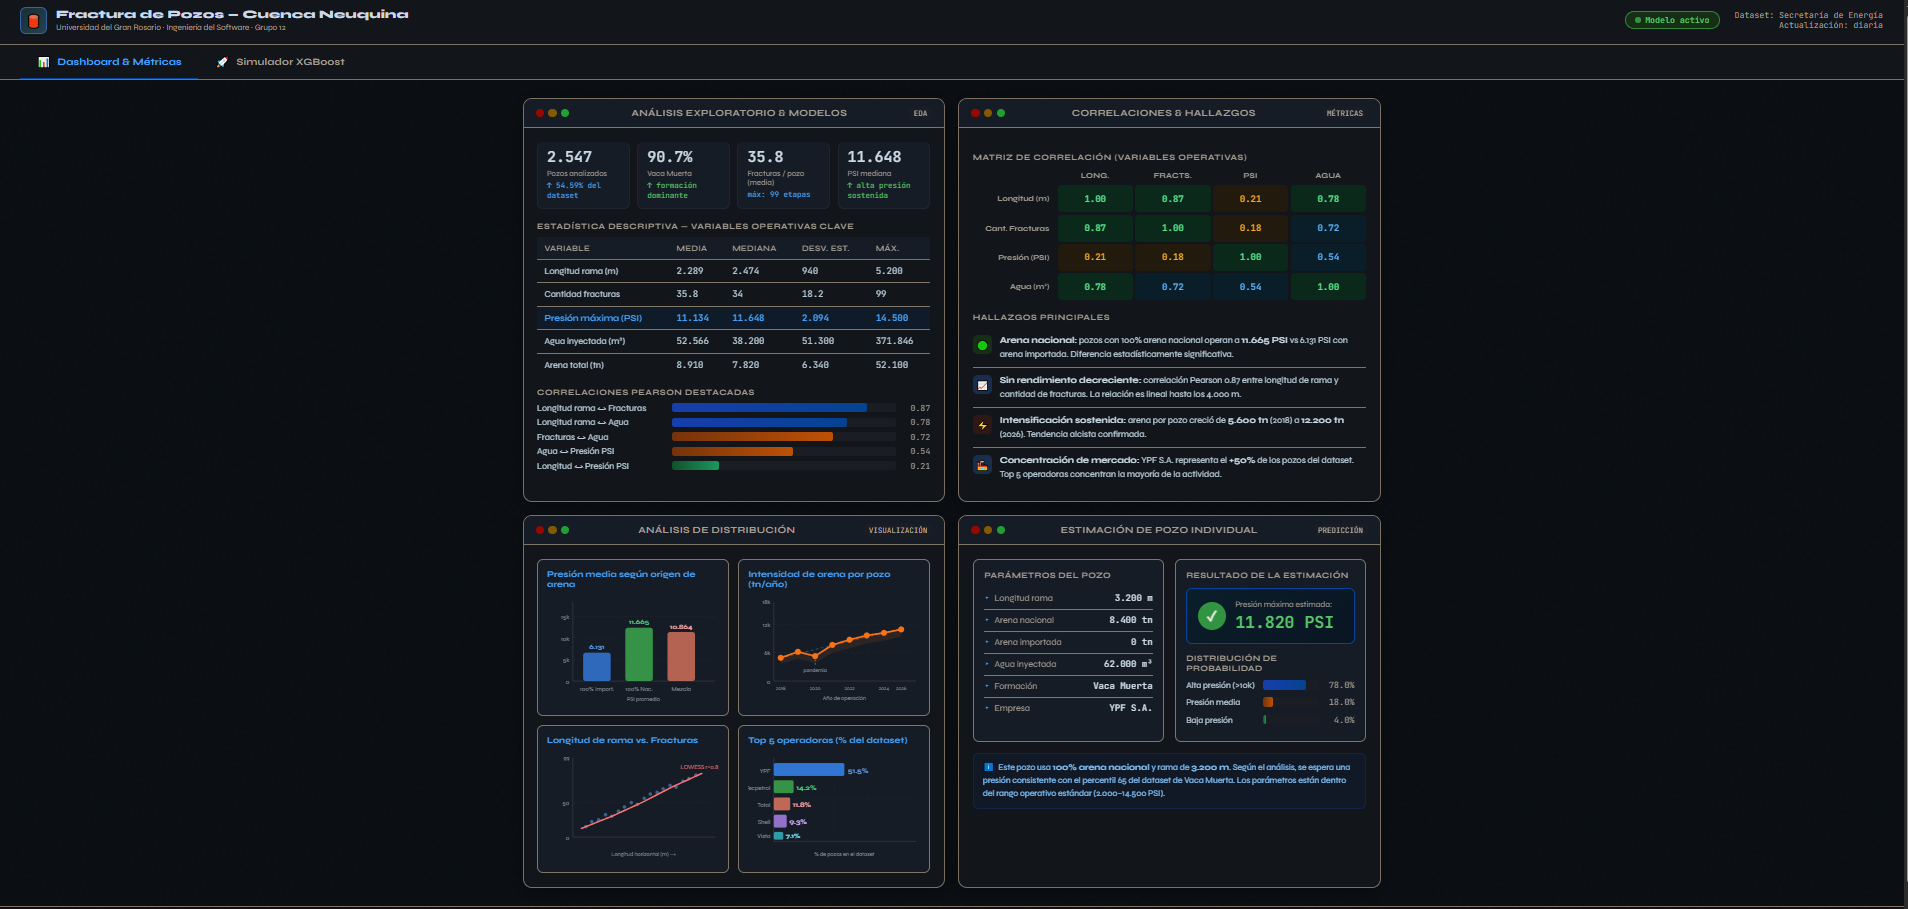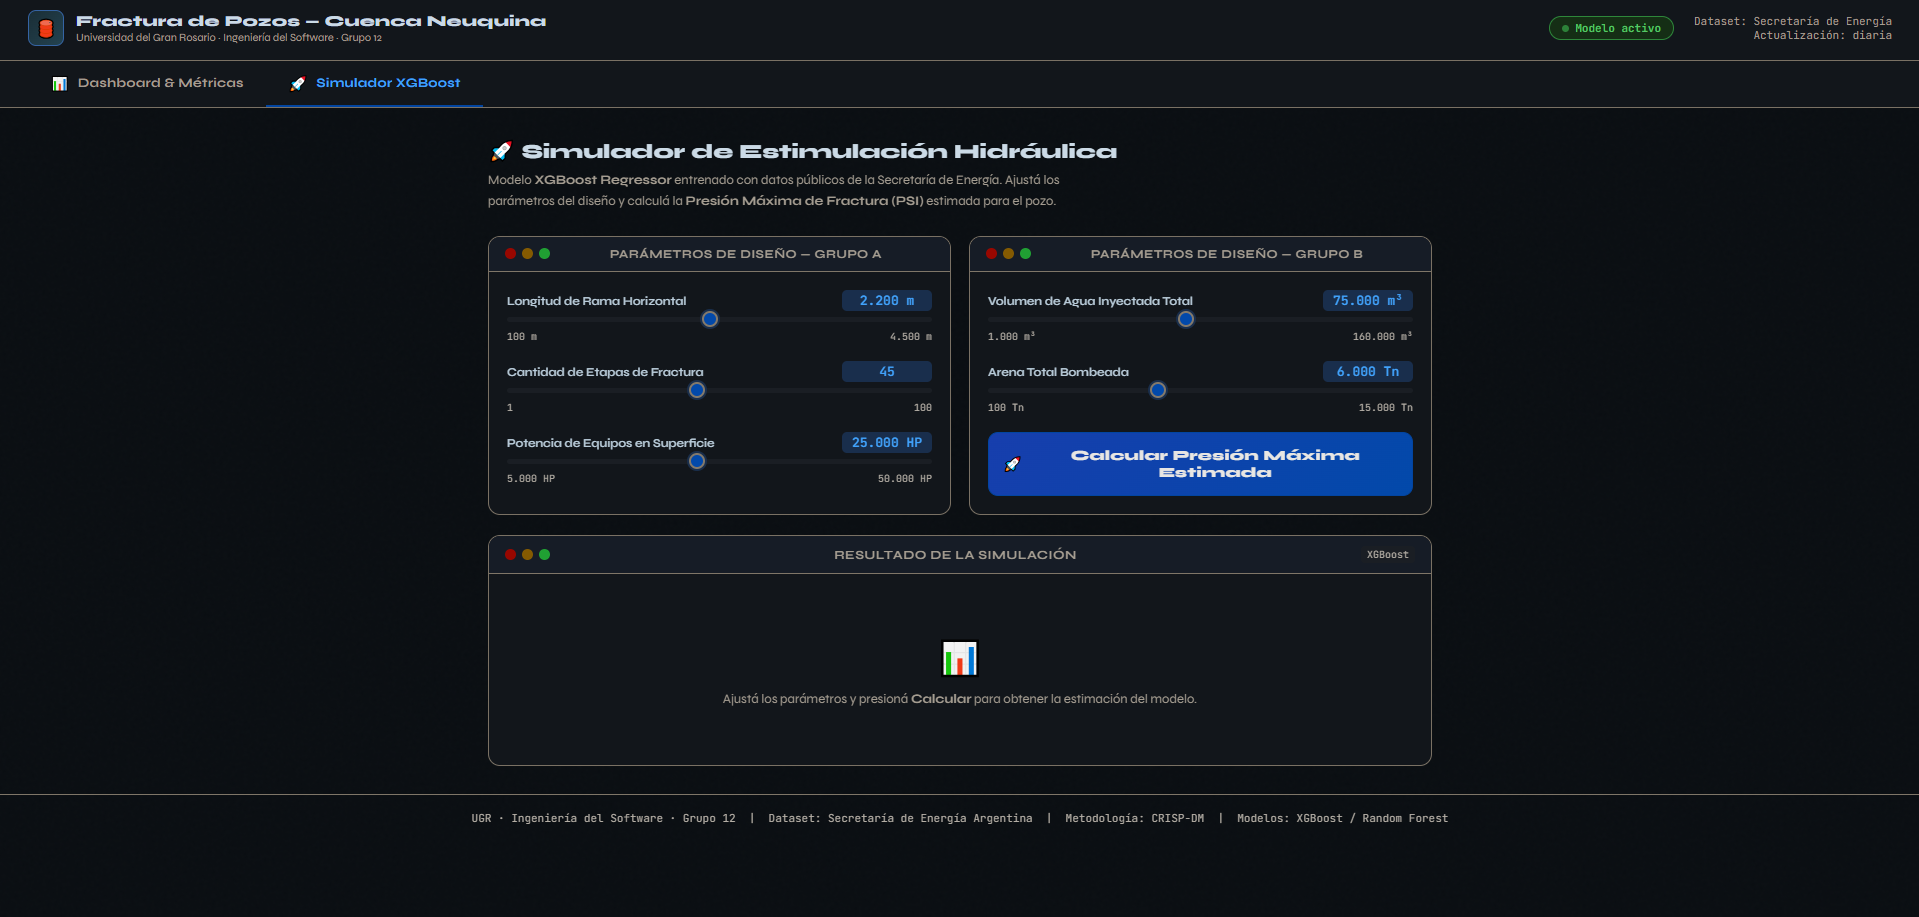